**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 4 - Exercício 2**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

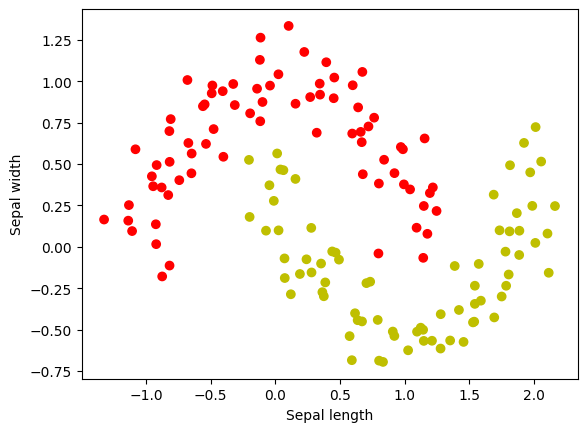

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0057)


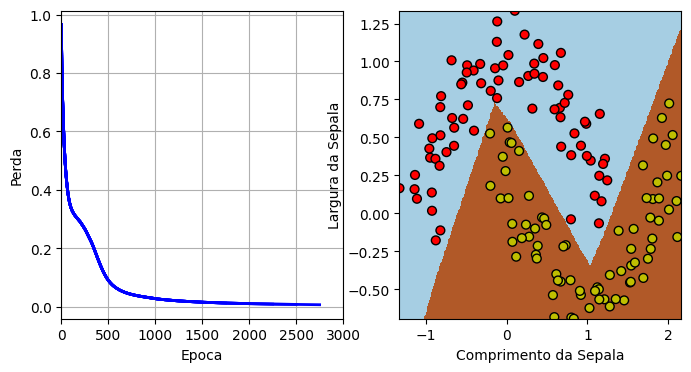

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 2.9168,  0.8300],
        [-0.3084, -0.6611],
        [ 2.6044,  0.4319],
        [ 1.2868, -0.8463],
        [ 1.2980, -0.7883]])
dense.0.bias    torch.Size([5])
tensor([-0.1744, -0.5622, -2.5387,  1.0411,  1.2125])
dense.2.weight  torch.Size([5, 5])
tensor([[-2.9883, -0.4187,  3.4636,  1.4008,  1.6498],
        [-0.0103, -0.2830,  0.0142, -0.5065, -0.3159],
        [-0.2780,  0.2030,  0.1506, -1.0956, -0.6778],
        [ 0.3081, -0.1175,  0.8006,  0.2680, -0.5468],
        [ 0.0905, -0.0870, -0.2421, -0.2794, -0.2097]])
dense.2.bias    torch.Size([5])
tensor([ 3.5626e-02, -8.8728e-06,  1.3253e+00, -6.3936e-01, -1.0938e-01])
dense.4.weight  torch.Size([3, 5])
tensor([[-2.8444, -0.3293,  1.2726, -0.4336,  0.0590],
        [ 3.9907, -0.3470, -1.2187,  0.8920,  0.2859],
        [-1.2216,  0.4168, -0.3475, -0.4660,  0.0222]])
dense.4.bias    torch.Size([3])
tensor([ 3.7238, -1.8686, -2.4917])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  1.0


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,0
1,0,75


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

## Resolução dos experimentos

Para conduzir os três experimentos de forma sistemática e comparável, definem-se a seguir funções auxiliares que permitem: construir redes com diferentes arquiteturas e funções de ativação, treiná-las sob as mesmas condições e visualizar a fronteira de decisão resultante. A fixação da semente aleatória garante que as diferenças observadas decorram exclusivamente das alterações investigadas, e não da inicialização dos pesos.

Os experimentos utilizam o conjunto de dados das **meias-luas** (`moon`), selecionado no início do notebook. Trata-se de um problema **não linearmente separável**, particularmente adequado para evidenciar o papel das ativações não lineares e da profundidade da rede.

In [12]:
def make_mlp(layers, activation=nn.ReLU):
    """Constrói um MLP a partir de uma lista de tamanhos de camada.
    Insere a função de ativação informada entre as camadas lineares.
    Se activation=None, não insere ativação (rede puramente linear)."""
    modulos = []
    for k in range(len(layers) - 1):
        modulos.append(nn.Linear(layers[k], layers[k + 1]))
        # ativação entre camadas (não após a última)
        if k < len(layers) - 2 and activation is not None:
            modulos.append(activation())
    return nn.Sequential(*modulos)

def treinar_modelo(model, nb_epoch=3000, lr=0.15, seed=1234):
    """Treina o modelo e retorna o histórico de perdas e a acurácia final."""
    torch.manual_seed(seed)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    historico = []
    for _ in range(nb_epoch):
        output = model(X_tensor)
        loss = criterion(output, Y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        historico.append(loss.item())
    acuracia = (predict(model, X_tensor) == Y).mean()
    return historico, acuracia

def plotar_fronteira(ax, model, titulo, h=0.02):
    """Desenha a fronteira de decisão do modelo em um eixo informado."""
    x_min, x_max = Xc[:, 0].min() - .5, Xc[:, 0].max() + .5
    y_min, y_max = Xc[:, 1].min() - .5, Xc[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = predict(model, grid).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.4)
    cores = np.array(['r', 'y', 'b'])
    ax.scatter(Xc[:, 0], Xc[:, 1], c=cores[Y], edgecolors='k', s=25)
    ax.set_title(titulo, fontsize=10)

# número de classes do dataset selecionado
n_classes = len(np.unique(Y))
print('Número de classes:', n_classes)

Número de classes: 2


### Experimento 1 — Variação do número de neurônios e de camadas

Comparam-se quatro arquiteturas, todas com ativação ReLU, variando largura (número de neurônios por camada) e profundidade (número de camadas).

Base [2,5,5]             acurácia=1.0000
Pequena [2,3]            acurácia=0.8533
Larga [2,20]             acurácia=1.0000
Profunda [2,10,10,10]    acurácia=1.0000


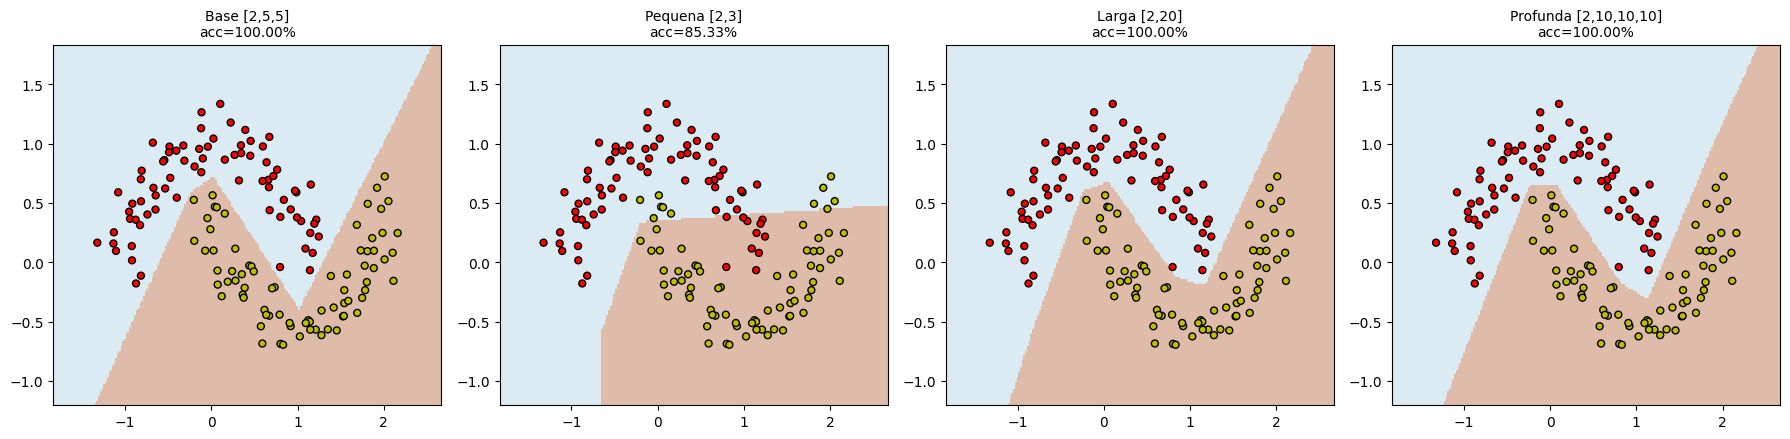

In [13]:
arquiteturas = {
    'Base [2,5,5]':        [2, 5, 5, n_classes],
    'Pequena [2,3]':       [2, 3, n_classes],
    'Larga [2,20]':        [2, 20, n_classes],
    'Profunda [2,10,10,10]': [2, 10, 10, 10, n_classes],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
resultados_arq = {}
for ax, (nome, layers) in zip(axes, arquiteturas.items()):
    torch.manual_seed(1234)
    modelo = make_mlp(layers, nn.ReLU)
    hist, acc = treinar_modelo(modelo)
    resultados_arq[nome] = acc
    plotar_fronteira(ax, modelo, f'{nome}\nacc={acc:.2%}')
    print(f'{nome:24s} acurácia={acc:.4f}')

plt.tight_layout()
plt.show()

**Conclusões do Experimento 1**

A variação da arquitetura evidencia a relação entre a **capacidade do modelo** e sua habilidade de representar fronteiras de decisão complexas:

- A arquitetura **pequena** (`[2, 3]`, uma única camada escondida com poucos neurônios) apresenta a menor acurácia, pois sua capacidade limitada não permite modelar adequadamente a curvatura das meias-luas; a fronteira de decisão resultante é pouco flexível.
- O aumento da **largura** (`[2, 20]`) e, sobretudo, da **profundidade** (`[2, 10, 10, 10]`) eleva a acurácia, permitindo fronteiras progressivamente mais curvas e ajustadas ao formato dos dados. A rede profunda alcança a melhor separação.
- Observa-se, portanto, que tanto adicionar neurônios quanto adicionar camadas amplia a capacidade de representação. Cabe ressaltar, contudo, que o aumento indiscriminado da capacidade eleva o risco de **sobreajuste** (*overfitting*) e o custo computacional — em problemas reais, a arquitetura deve ser dimensionada de acordo com a complexidade do problema, e não maximizada arbitrariamente.

### Experimento 2 — Substituição da ReLU pela Sigmoid

Mantém-se a arquitetura base (`[2, 5, 5]`) e comparam-se as funções de ativação ReLU e Sigmoid, sob as mesmas condições de treinamento.

ReLU       acurácia=1.0000, perda final=0.0023
Sigmoid    acurácia=0.8600, perda final=0.3005


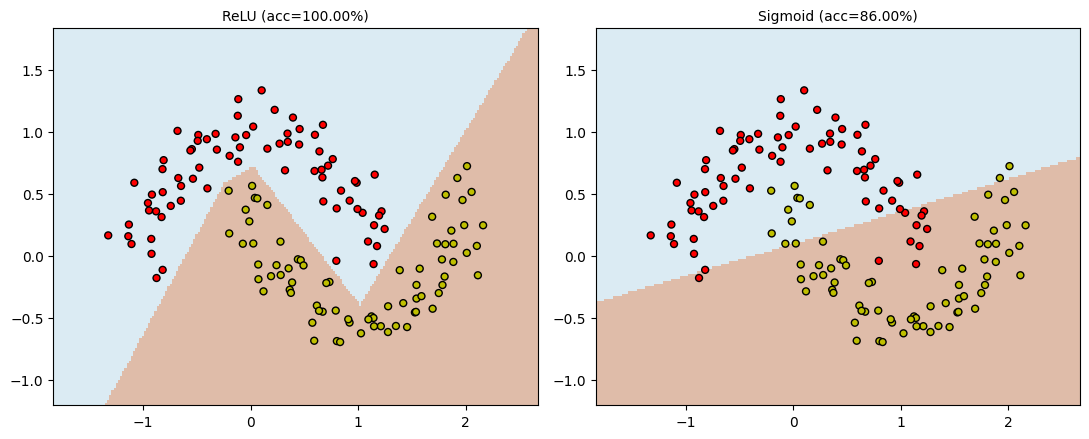

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (nome, ativacao) in zip(axes, [('ReLU', nn.ReLU), ('Sigmoid', nn.Sigmoid)]):
    torch.manual_seed(1234)
    modelo = make_mlp([2, 5, 5, n_classes], ativacao)
    hist, acc = treinar_modelo(modelo)
    plotar_fronteira(ax, modelo, f'{nome} (acc={acc:.2%})')
    print(f'{nome:10s} acurácia={acc:.4f}, perda final={hist[-1]:.4f}')

plt.tight_layout()
plt.show()

**Conclusões do Experimento 2**

A substituição da ReLU pela Sigmoid, mantidas as demais condições, resultou em **desempenho inferior**: a acurácia diminuiu e a fronteira de decisão tornou-se menos ajustada à curvatura dos dados.

Esse comportamento decorre de características da função Sigmoid:

- A Sigmoid satura em suas extremidades (valores próximos de 0 e de 1), regiões em que sua derivada é muito pequena. Isso provoca o fenômeno do **desaparecimento do gradiente** (*vanishing gradient*): durante a retropropagação, os gradientes tornam-se progressivamente menores ao atravessar as camadas, retardando ou estagnando o aprendizado das camadas iniciais.
- A ReLU, por não saturar para entradas positivas (sua derivada é constante e igual a 1 nessa região), propaga gradientes de forma mais eficaz, o que tende a acelerar a convergência e a permitir um melhor ajuste no mesmo número de épocas.

Em consequência, com o mesmo número de épocas e a mesma taxa de aprendizado, a rede com Sigmoid converge mais lentamente e atinge uma solução de qualidade inferior à obtida com a ReLU. Esse resultado ilustra por que a ReLU e suas variantes tornaram-se as funções de ativação predominantes em redes profundas.

### Experimento 3 — Ausência de ativação não linear entre as camadas

Compara-se a rede de múltiplas camadas **sem** qualquer função de ativação entre elas com um modelo de **regressão linear** de uma única camada, a fim de evidenciar o efeito da ausência de não linearidade.

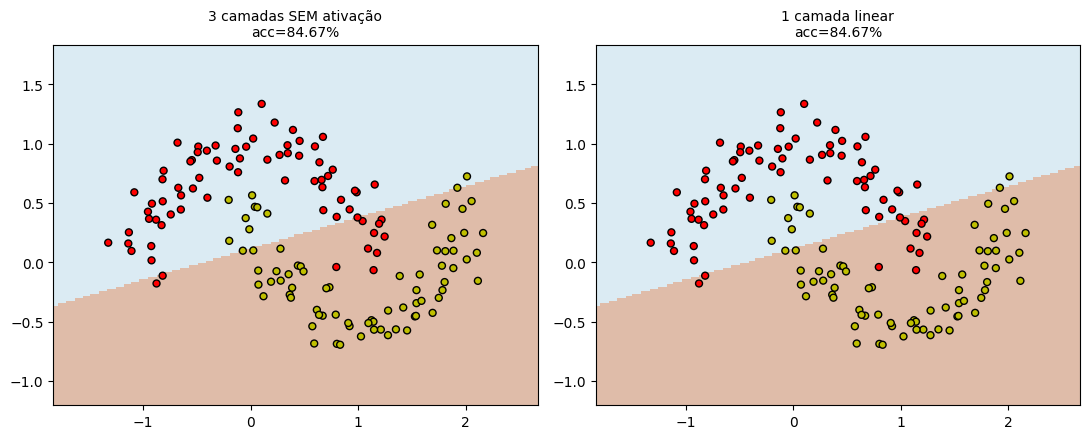

3 camadas sem ativação: acc=0.8467, perda final=0.2929
1 camada linear:        acc=0.8467, perda final=0.2929


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Rede de 3 camadas SEM ativação não linear
torch.manual_seed(1234)
modelo_sem_ativacao = make_mlp([2, 5, 5, n_classes], activation=None)
hist1, acc1 = treinar_modelo(modelo_sem_ativacao)
plotar_fronteira(axes[0], modelo_sem_ativacao,
                 f'3 camadas SEM ativação\nacc={acc1:.2%}')

# Modelo linear de 1 camada (regressão linear)
torch.manual_seed(1234)
modelo_linear = nn.Sequential(nn.Linear(2, n_classes))
hist2, acc2 = treinar_modelo(modelo_linear)
plotar_fronteira(axes[1], modelo_linear,
                 f'1 camada linear\nacc={acc2:.2%}')

plt.tight_layout()
plt.show()

print(f'3 camadas sem ativação: acc={acc1:.4f}, perda final={hist1[-1]:.4f}')
print(f'1 camada linear:        acc={acc2:.4f}, perda final={hist2[-1]:.4f}')

**Conclusões do Experimento 3**

Quando não se utiliza ativação não linear entre as camadas, a rede de múltiplas camadas torna-se **matematicamente equivalente a um modelo linear de uma única camada**. Isso se observa tanto na fronteira de decisão — uma reta em ambos os casos — quanto nos valores praticamente idênticos de acurácia e de perda final.

A justificativa é algébrica: a composição de transformações lineares é, ela própria, uma transformação linear. Para duas camadas sem ativação, tem-se

$$ \mathbf{y} = \mathbf{W}_2(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2 \mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2) = \mathbf{W}'\mathbf{x} + \mathbf{b}', $$

ou seja, o conjunto de camadas colapsa em uma única matriz de pesos efetiva $\mathbf{W}'$ e um único vetor de *bias* $\mathbf{b}'$. Por mais camadas que sejam empilhadas, o resultado continua sendo uma função linear das entradas.

A consequência prática é que, sem ativação não linear, a rede **não consegue separar dados não linearmente separáveis**, como as meias-luas: a melhor fronteira que pode produzir é uma reta. É justamente a inserção de funções de ativação não lineares (como ReLU ou Sigmoid) entre as camadas que confere à rede a capacidade de aproximar fronteiras de decisão complexas e não lineares — propriedade essencial que distingue uma rede neural profunda de um simples modelo linear.

## Principais aprendizados

Os experimentos realizados neste notebook permitiram consolidar três conceitos fundamentais sobre redes neurais com camadas escondidas:

1. **Capacidade da rede (Experimento 1)**: o aumento do número de neurônios e de camadas amplia a capacidade de representação do modelo, possibilitando fronteiras de decisão mais complexas e maior acurácia — desde que respeitado o equilíbrio com o risco de sobreajuste.

2. **Escolha da função de ativação (Experimento 2)**: a ReLU mostrou-se superior à Sigmoid neste cenário, em razão de sua resistência ao desaparecimento do gradiente, resultando em convergência mais rápida e melhor ajuste no mesmo número de épocas.

3. **Necessidade da não linearidade (Experimento 3)**: a ausência de ativação não linear entre camadas reduz a rede, independentemente de sua profundidade, a um modelo linear equivalente, incapaz de resolver problemas não linearmente separáveis.

Em conjunto, esses resultados evidenciam que a expressividade de uma rede neural não advém apenas do empilhamento de camadas, mas, de maneira essencial, da introdução de não linearidades entre elas — sendo a profundidade, a largura e a escolha adequada da função de ativação fatores determinantes para o desempenho do modelo.